In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Reserve price range: [670, 920] \
Sell price: 920

The distribution of the bids is uniformly distributed at increments of 5 between 670 and 920 (inclusive on both ends). 

You may submit **two bids**. If the first bid is **higher** than the reserve price, they trade with you at your first bid. If your second bid is **higher** than the reserve price of a counterparty and **higher** than the mean of second bids of all players you trade at your second bid. If your second bid is **higher** than the reserve price, but **lower** than or **equal** to the mean of second bids of all players, the chance of a trade rapidly decreases: you will trade at your second bid **but** your PNL is penalised by 

$$
\left(\frac{920 - \text{avg\_b2}}{920 - b2}\right)^3
$$

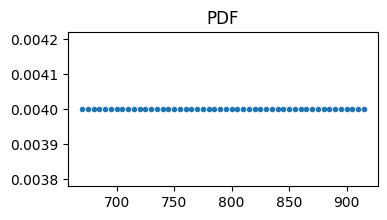

In [2]:
d_price = 5
p_low, p_high = 670, 920
p_sell = 920
prices = np.arange(p_low, p_high, d_price)  # reserve price

a = 1 / (p_high - p_low)

pdf = []
for p in prices:
    pdf.append(a)

plt.figure(figsize=(4, 2))
plt.scatter(prices, pdf, marker='.')
plt.title('PDF')
plt.show()

In [3]:
def calc_cdf(p, a=a):
    if p <= p_low:
        return 0
    elif p_low <= p <= p_high:
        return a * (p - p_low)
    else:
        return 1

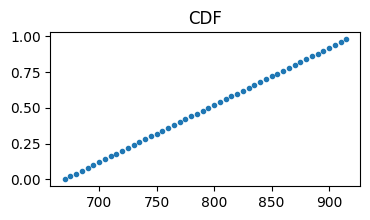

In [4]:
cdf = []
for p in prices:
    cdf.append(calc_cdf(p, a))
cdf = np.array(cdf)

plt.figure(figsize=(4, 2))
plt.scatter(prices, cdf, marker='.')
plt.title('CDF')
plt.show()

In [5]:
def calc_expected_profit(bid1, bid2):
    return (p_sell - bid1) * calc_cdf(bid1) + (p_sell - bid2) * (calc_cdf(bid2) - calc_cdf(bid1))

In [6]:
profits = {}
for bid1 in np.arange(p_low, p_high, d_price):
    for bid2 in np.arange(bid1, p_high, d_price):
        profit = calc_expected_profit(bid1, bid2)
        profits[(bid1, bid2)] = profit

max_profit = max(profits.values())
best_bids = [k for k, v in profits.items() if v == max_profit]
print(f'Bid 1: {best_bids[0][0]}, Bid 2: {best_bids[0][1]}, profit: {max_profit}')

Bid 1: 755, Bid 2: 840, profit: 83.30000000000001


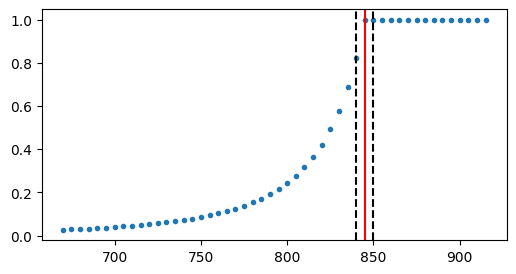

In [7]:
lis = []
avg = 845
for bid2 in range(p_low, p_high, d_price):
    avg_ratio = ((p_high - avg) / (p_high - bid2)) ** 3
    if bid2 < avg:
        lis.append(avg_ratio)
    else:
        lis.append(1)

plt.figure(figsize=(6, 3))
plt.scatter(range(p_low, p_high, d_price), lis, marker='.')
plt.axvline(avg, c='r')
plt.axvline(avg + 5, c='k', linestyle = 'dashed')
plt.axvline(avg - 5, c='k', linestyle = 'dashed')
plt.show()

In [8]:
def calc_expected_profit_avg(bid1, bid2, avg):
    if bid2 > avg:
        return calc_expected_profit(bid1, bid2)
    else:
        avg_ratio = ((p_high - avg) / (p_high - bid2)) ** 3
        return (p_high - bid1) * calc_cdf(bid1) + (p_high - bid2) * (calc_cdf(bid2) - calc_cdf(bid1)) * avg_ratio

In [9]:
avg = 845
profits_1 = {}
for bid1 in np.arange(p_low, p_high, d_price):
    for bid2 in np.arange(bid1, p_high, d_price):
        profit = calc_expected_profit_avg(bid1, bid2, avg=avg)
        profits_1[(bid1, bid2)] = profit

max_profit = max(profits_1.values())
best_bids = [k for k, v in profits_1.items() if v == max_profit]
print(f'Bid 1: {best_bids[0][0]}, Bid 2: {best_bids[0][1]}, profit: {max_profit}')

Bid 1: 755, Bid 2: 845, profit: 83.10000000000001


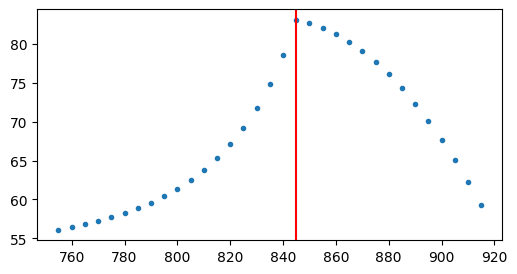

In [10]:
profits = {}
bid1 = 755
for bid2 in np.arange(bid1, p_high, d_price):
    profit = calc_expected_profit_avg(bid1, bid2, avg=avg)
    profits[bid2] = profit

max_profit = max(profits.values())
best_bid = [k for k, v in profits.items() if v == max_profit]

plt.figure(figsize=(6, 3))
plt.scatter(profits.keys(), profits.values(), marker='.')
plt.axvline(avg, c='r')
plt.show()

In [11]:
avg = 850
profits_2 = {}
for bid1 in np.arange(p_low, p_high, d_price):
    for bid2 in np.arange(bid1, p_high, d_price):
        profit = calc_expected_profit_avg(bid1, bid2, avg=avg)
        profits_2[(bid1, bid2)] = profit

max_profit = max(profits_2.values())
best_bids = [k for k, v in profits_2.items() if v == max_profit]
print(f'Bid 1: {best_bids[0][0]}, Bid 2: {best_bids[0][1]}, profit: {max_profit}')

Bid 1: 760, Bid 2: 850, profit: 82.8


In [12]:
print("If avg=845:")
print(f"PnL of bidding 755 and 845: {profits_1[(755, 845)]}")
print(f"PnL of bidding 760 and 850: {profits_1[(760, 850)]}")
print(f"Diff: {profits_1[(755, 845)] - profits_1[(760, 850)]}")

If avg=845:
PnL of bidding 755 and 845: 83.10000000000001
PnL of bidding 760 and 850: 82.8
Diff: 0.30000000000001137


In [13]:
print("If avg=850:")
print(f"PnL of bidding 755 and 845: {profits_2[(755, 845)]}")
print(f"PnL of bidding 760 and 850: {profits_2[(760, 850)]}")
print(f"Diff: {profits_2[(760, 850)] - profits_2[(755, 845)]}")

If avg=850:
PnL of bidding 755 and 845: 78.052
PnL of bidding 760 and 850: 82.8
Diff: 4.7479999999999905


In [21]:
my_bid1, my_bid2 = 760, 850
print(f"Selected bids: {my_bid1}, {my_bid2}")

Selected bids: 760, 850


In [15]:
print("--- RACE TO THE TOP SIMULATION ---")
for simulated_avg in range(840, 900, 5):
    profits = {}
    for bid1 in np.arange(p_low, p_high, d_price):
        for bid2 in np.arange(bid1, p_high, d_price):
            profit = calc_expected_profit_avg(bid1, bid2, avg=simulated_avg)
            profits[(bid1, bid2)] = profit

    max_profit = max(profits.values())
    best_bids = [k for k, v in profits.items() if v == max_profit]
    
    print(f"If community avg is {simulated_avg} -> Optimal Bids: {best_bids[0]}, Expected Profit: {max_profit:.2f}")

--- RACE TO THE TOP SIMULATION ---
If community avg is 840 -> Optimal Bids: (np.int64(755), np.int64(840)), Expected Profit: 83.30
If community avg is 845 -> Optimal Bids: (np.int64(755), np.int64(845)), Expected Profit: 83.10
If community avg is 850 -> Optimal Bids: (np.int64(760), np.int64(850)), Expected Profit: 82.80
If community avg is 855 -> Optimal Bids: (np.int64(760), np.int64(855)), Expected Profit: 82.30
If community avg is 860 -> Optimal Bids: (np.int64(765), np.int64(860)), Expected Profit: 81.70
If community avg is 865 -> Optimal Bids: (np.int64(765), np.int64(865)), Expected Profit: 80.90
If community avg is 870 -> Optimal Bids: (np.int64(770), np.int64(870)), Expected Profit: 80.00
If community avg is 875 -> Optimal Bids: (np.int64(770), np.int64(875)), Expected Profit: 78.90
If community avg is 880 -> Optimal Bids: (np.int64(775), np.int64(880)), Expected Profit: 77.70
If community avg is 885 -> Optimal Bids: (np.int64(775), np.int64(885)), Expected Profit: 76.30
If co

# Final results

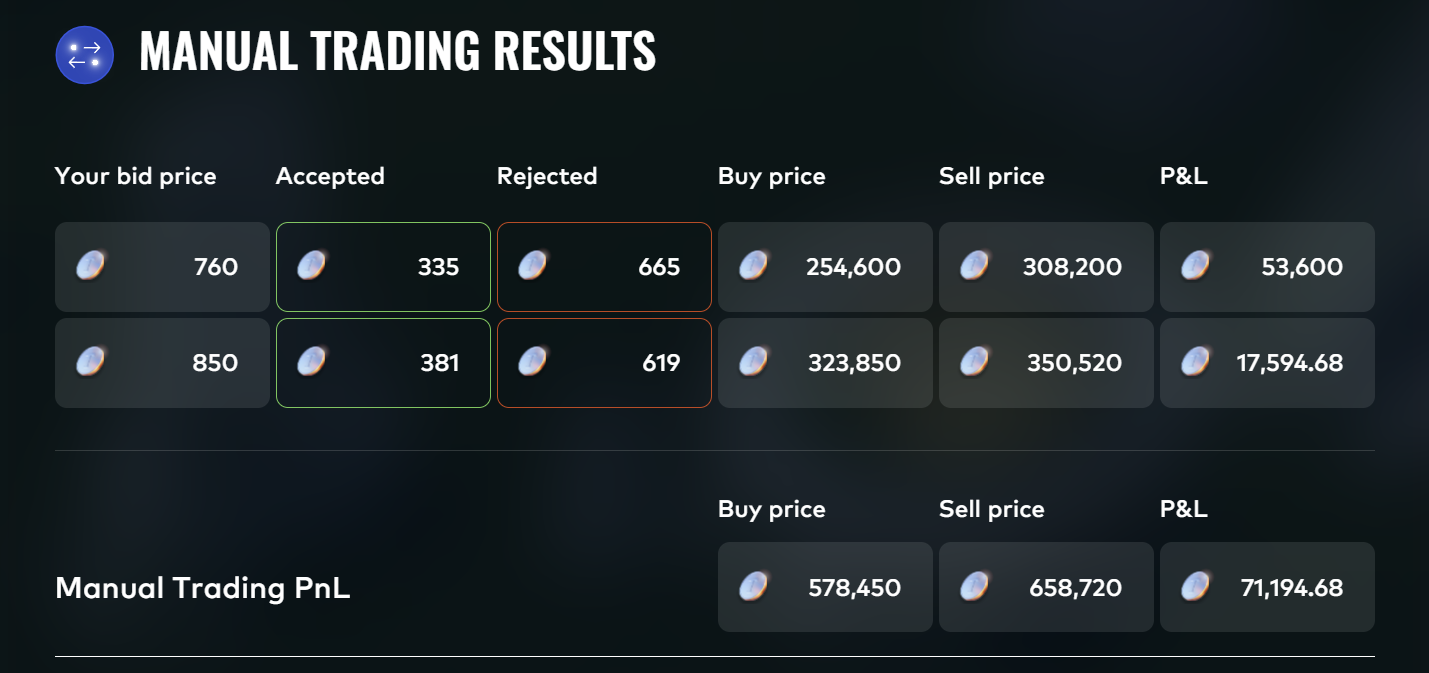

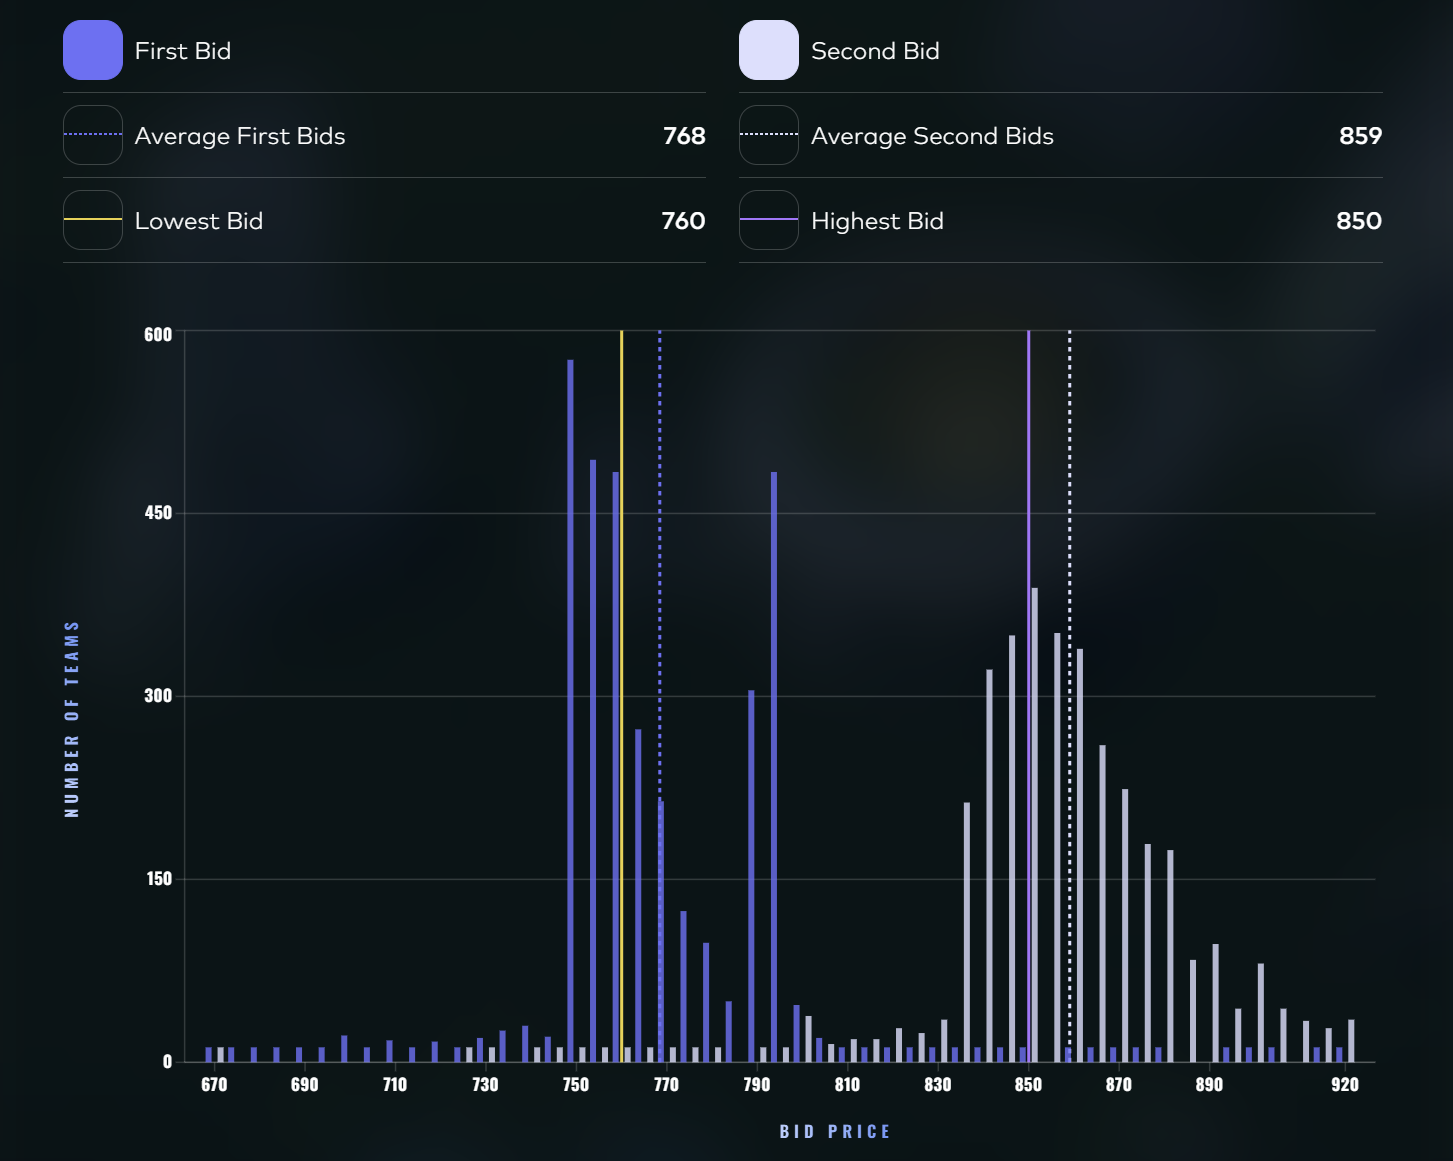

In [16]:
final_pnl = 71195

In [24]:
avg = 859
profits = {}
for bid1 in np.arange(p_low, p_high, d_price):
    for bid2 in np.arange(bid1, p_high, d_price):
        profit = calc_expected_profit_avg(bid1, bid2, avg=avg)
        profits[(bid1, bid2)] = profit

max_profit = max(profits.values())
best_bids = [k for k, v in profits.items() if v == max_profit]
print(f'Bid 1: {best_bids[0][0]}, Bid 2: {best_bids[0][1]}, profit: {max_profit}')
print(f"My bids: {my_bid1}, {my_bid2} --> Expected profit: {profits[(my_bid1, my_bid2)]}")
print(f"Final PnL: {final_pnl}")

Bid 1: 765, Bid 2: 860, profit: 81.7
My bids: 760, 850 --> Expected profit: 74.2761551020408
Final PnL: 71195
